In [13]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import random
from tqdm import trange
import random

I = 8
K = 4
DEFAULT_N_ITEMS_BASKET = 5
N_BASKET = 20
TRAINING_EPOCHS = 200
TRAINING_BATCH_SIZE = 10
L_R = 0.01
K_NOISE = 3



Wi = tf.Variable(tf.random.normal((K, I), stddev=0.1), name='Wi')
Wo = tf.Variable(tf.random.normal((I, K), stddev=0.1), name='Wo')
wa = tf.Variable(tf.random.normal((K,), stddev=0.1), name='wa')





In [14]:
class Items:
    def __init__(self, Wi, Wo, n_items = I, embedding_dim = K):
        self.n_items = n_items
        self.embedding_dim = embedding_dim
        self.input_embedding_Wi = Wi
        self.output_embedding_Wo  = Wo
        self.one_hots = tf.cast(tf.keras.utils.to_categorical(tf.range(self.n_items, dtype=tf.int64).numpy(),
                                                      num_classes=self.n_items), tf.float32)
        self._one_hots_embedded = None
        self.embed_from_one_hot()
    
    def __repr__(self):
        return f"Items(n_items={self.n_items}, embedding_dim={self.embedding_dim})"

    def embed_from_one_hot(self):
        self._one_hots_embedded = tf.tensordot(self.input_embedding_Wi, self.one_hots, axes=1)
    
    def update_embedding(self, new_Wi, new_Wo):
        self.input_embedding_Wi = new_Wi
        self.output_embedding_Wo = new_Wo
        self.embed_from_one_hot()

In [15]:
class Basket(Items):
    def __init__(self, Wi, Wo, n_items = I, embedding_dim= K, basket_items=None, n_items_basket=DEFAULT_N_ITEMS_BASKET):
        super().__init__(Wi, Wo, n_items, embedding_dim)
        if basket_items != None:
            self.basket_items = tf.convert_to_tensor(basket_items, dtype=tf.int32)
            self.n_items_basket = len(self.basket_items)
        else:
            self.basket_items = None
            self.n_items_basket = n_items_basket
        
        if self.basket_items == None:
            self._sample()
    
    def __repr__(self):
        return f"{self.basket_items.numpy()}"
  
    def _sample(self):
        indices = tf.range(self.n_items, dtype=tf.int64)
        shuffled = tf.random.shuffle(indices)
        sample = shuffled[:self.n_items_basket]
        self.basket_items= sample
        return sample
    
    def describe(self):
        print("Transaction:", self.basket_items.numpy())

    
    def update_embedding(self, new_Wi, new_Wo):
        super().update_embedding(new_Wi, new_Wo)

In [58]:
class Context:
    def __init__(self, basket, wa, target_item = None):
        self.Theta = [basket.input_embedding_Wi, 
                      wa, 
                      basket.output_embedding_Wo]
        self.basket = basket
        if target_item is None:
            target_item = random.choice(basket.basket_items.numpy())
        elif target_item not in basket.basket_items.numpy():
            raise ValueError("Target item must be part of the transaction items.")
        
        self.target_item = target_item
        self.context_items = tf.boolean_mask(self.basket.basket_items, self.basket.basket_items != target_item)
        self.context_onehots = tf.gather(self.basket._one_hots_embedded, self.context_items, axis=1)
        self.context_embedding = None

    
    def __repr__(self):
        return f"context items ={self.context_items.numpy()}"
            
    

    def _context_embed(self):
        Wi, wa, Wo = self.Theta
        context_items_embeding = self.context_onehots
        e_h = tf.linalg.matvec(tf.transpose(context_items_embeding),wa) 
        exponents = tf.exp(e_h)
        alpha_weights = exponents / tf.reduce_sum(exponents)
        self.context_embedding = tf.tensordot(context_items_embeding,alpha_weights, axes=1)


    def score(self, item):
        Wi, wa, Wo = self.Theta
        self._context_embed()
        return tf.tensordot(Wo[item], self.context_embedding, axes=1)
        
    
    def describe(self):
        self._context_embed()
        print("Target item is", self.target_item," in the context:",self.context_items.numpy() )
        print("Context embedding shape:", self.context_embedding.shape)
        print("Target item score:", self.score(self.target_item).numpy())

    def update_embedding(self, new_Wi, new_Wo, new_wa):
        self.Theta[0] = new_Wi
        self.Theta[2] = new_Wo
        self.Theta[1] = new_wa
        self._context_embed()

In [59]:
class Trainer:
    def __init__(self, data, Theta, lr = L_R, K_noise = K_NOISE, epochs = TRAINING_EPOCHS):
        self.contexts_and_target_item = data
        self.all_items = self.contexts_and_target_item[0][0].basket.n_items
        self.Theta = Theta
        self.lr = lr
        self.K_noise = K_noise
        self.optimizer = tf.keras.optimizers.Adam(self.lr)
        self.epochs = epochs
        self.Q = [1.0 / (self.all_items-1) for _ in range(self.all_items)]


    def custom_loss(self, context, target_item):
        basket_items = context.basket.basket_items  
        all_items = tf.range(self.all_items, dtype=basket_items.dtype)
        mask = ~tf.reduce_any(tf.equal(all_items[:, None], basket_items[None, :]), axis=1)
        neg_pool = tf.boolean_mask(all_items, mask)
        neg_items = tf.random.shuffle(neg_pool)[:self.K_noise]
        KQ = self.K_noise * self.Q[target_item]
        def P_1_c(i_c):
            S = context.score(i_c)
            return tf.exp(3*S) / (tf.exp(3*S)+ KQ)
        def P_0_c(i_c):
            S = context.score(i_c)
            return 1 - (tf.exp(3*S) / (tf.exp(3*S)+ KQ))
        loss = -tf.math.log(P_1_c(target_item) + 1e-10)
        for i in neg_items:
            loss -= tf.math.log(P_0_c(i) + 1e-10)
        return loss

    def forward(self, context, target_item):
        return self.custom_loss(context, target_item)
    


    def fit(self, verbose = True, batch_size = TRAINING_BATCH_SIZE):
        loss_history = [float('inf')]*10
        n = len(self.contexts_and_target_item)


        for epoch in trange(self.epochs, desc="Training epochs"):
            self.contexts_and_target_item[0][0].basket.update_embedding(self.Theta[0], self.Theta[2])
            batch = random.sample(self.contexts_and_target_item, min(batch_size, n))

            with tf.GradientTape() as tape:
                total_loss = 0.0
                for ctx, target_item in batch:
                    ctx.update_embedding(self.Theta[0], self.Theta[2], self.Theta[1])
                    loss = self.forward(ctx, target_item)
                    total_loss += loss
                total_loss = total_loss / len(self.contexts_and_target_item)
            if total_loss > 2*min(loss_history[-10:]):
                continue

            Wi, wa, Wo = self.Theta
            grads = tape.gradient(total_loss, [Wi, wa, Wo])
            self.optimizer.apply_gradients(zip(grads, [Wi, wa, Wo]))
            loss_history.append(total_loss.numpy())
            #if verbose and epoch % 50 == 0:
                ##print(f"Epoch {epoch}, Loss: {total_loss.numpy():.4f}")
  
        return loss_history


In [65]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import random
from tqdm import trange

I = 8
K = 8
DEFAULT_N_ITEMS_BASKET = 5
N_BASKET = 200
TRAINING_EPOCHS = 400
TRAINING_BATCH_SIZE = 50
L_R = 0.05
K_NOISE = 3



Wi = tf.Variable(tf.random.normal((K, I), stddev=0.1), name='Wi')
Wo = tf.Variable(tf.random.normal((I, K), stddev=0.1), name='Wo')
wa = tf.Variable(tf.random.normal((K,), stddev=0.1), name='wa')





In [66]:
# Constants for data generation
PROBA_COMPLEMENTARY_ITEMS = 0.7
PROBA_NEUTRAL_ITEMS = 0.3
DICT_ITEMS_CLASSES = {
    "nest0": ({0,1,2}, [-1, 1, 0, 0]) ,
    "nest1": ({3,4,5}, [1, -1, 0, 0]),
    "nest2": ({6}, [0, 0, -1, 0]),
    "nest3": ({7}, [0, 0, 0, -1])
}

ASSORTMENT = {0, 1, 2, 3, 4, 5, 6, 7}
AVAILABLE_SETS = list(KEY for KEY, VALUE in DICT_ITEMS_CLASSES.items() if VALUE[0].intersection(ASSORTMENT))

# Selection of the first item
def select_first_item():
    chosen_nest = random.choice(AVAILABLE_SETS)
    chosen_item = random.choice(list(DICT_ITEMS_CLASSES[chosen_nest][0]))
    return chosen_item, chosen_nest

# Complete the basket
def complete_basket(first_item, first_nest):
    basket = {first_item}
    first_key_index = int(first_nest[-1])
    for key in AVAILABLE_SETS:
        nest, relations = DICT_ITEMS_CLASSES[key]
        if relations[first_key_index] == 1 and random.random() < PROBA_COMPLEMENTARY_ITEMS:
            basket.add(random.choice(list(nest)))
        elif relations[first_key_index] == 0 and random.random() < PROBA_NEUTRAL_ITEMS:
            basket.add(random.choice(list(nest)))
    return basket


# Adding some random noise
def add_noise(basket):
    noise_proba = [0, 0.15]
    for item in ASSORTMENT:
        proba = random.choice(noise_proba)
        if item not in basket and random.random() < proba:
            basket.add(item)
    return list(basket)



        

In [67]:
## TESTING THE IMPLEMENTATION
if __name__ == "__main__":
    baskets = []
    baskets_count = 0
    while baskets_count < N_BASKET:
        first_item, first_nest = select_first_item()
        basket = complete_basket(first_item, first_nest)
        basket = add_noise(basket)
        if len(basket) > 3:
            baskets_count += 1
            baskets.append(basket)
    print(f"Generated {len(baskets)} baskets with items from {ASSORTMENT}.\n")

    def init_weights():
        Wi.assign(tf.random.normal((K, I), stddev=0.1))
        Wo.assign(tf.random.normal((I, K), stddev=0.1))
        wa.assign(tf.random.normal((K,), stddev=0.1))

    def accuracy(baskets_TI):
        correct = 0
        for context, target_item in baskets_TI:
            scores = np.array([context.score(i) for i in range(I)])
            context_items = set(context.context_items.numpy())
            for i in context_items:
                scores[i] = -np.inf
            most_relevant = np.argmax(scores)
            if most_relevant == target_item: correct += 1
        return correct / N_BASKET

    
    print("Initializing weights ... \n")
    init_weights()

    print("Creating (context, target_item) pairs from synthetic baskets ... \n")
    baskets_TI = []
    for i in range(N_BASKET):
        basket_items = baskets[i] 
        target_item = random.choice(basket_items)
        context = Context(Basket(Wi, Wo, basket_items = basket_items, n_items = I, embedding_dim = K, n_items_basket = DEFAULT_N_ITEMS_BASKET), wa=wa, target_item=target_item)
        #context._context_embed()
        baskets_TI.append((context, target_item))

    """
    print("Dataset illustration before training: \n")

    for basket, target_item in baskets_TI[:5]:
        context_items = set(basket.context_items.numpy())
        scores = np.array([basket.score(i) for i in range(I)])
        for i in context_items:
            scores[i] = -np.inf
        most_relevant = np.argmax(scores)
        print(basket, 'Target item:', target_item, 'Predicted item:', most_relevant)
    

    print("\n")
    print("Pre-training accuracy:", accuracy(baskets_TI), '\n')
    """

    print("Training the model ... \n")
    trainer = Trainer(baskets_TI, (Wi, wa, Wo), lr=L_R, K_noise=K_NOISE, epochs=TRAINING_EPOCHS)
    loss_history = trainer.fit()


    print("\n")
    print("Dataset illustration before training: \n")

    for basket, target_item in baskets_TI[:5]:
        context_items = set(basket.context_items.numpy())
        scores = np.array([basket.score(i) for i in range(I)])
        for i in context_items:
            scores[i] = -np.inf
        most_relevant = np.argmax(scores)
        print(basket, 'Target item:', target_item, 'Predicted item:', most_relevant)
    
    print("\n")
    print("post-training accuracy:", accuracy(baskets_TI), '\n')


    print("Plotting training loss curve ... \n")
    plt.figure(figsize=(8, 4))
    plt.plot(loss_history)
    plt.xlabel('Epoch')
    plt.ylabel('NCE Loss')
    plt.title('NCE Training Loss Curve')
    plt.grid(True)
    plt.show()


Generated 200 baskets with items from {0, 1, 2, 3, 4, 5, 6, 7}.

Initializing weights ... 

Creating (context, target_item) pairs from synthetic baskets ... 

Training the model ... 



Training epochs:   0%|          | 0/400 [00:00<?, ?it/s]/Users/souleiman.sbai/conda/lib/python3.12/site-packages/keras/src/optimizers/base_optimizer.py:855: UserWarning: Gradients do not exist for variables ['Wi:0'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(
Training epochs:   1%|▏         | 5/400 [00:03<04:50,  1.36it/s]


KeyboardInterrupt: 

Generating reference baskets ... 

Initializing weights ... 

Creating (context, target_item) pairs from synthetic baskets ... 

Training the model ... 



Training epochs:   0%|          | 0/400 [00:00<?, ?it/s]/Users/souleiman.sbai/conda/lib/python3.12/site-packages/keras/src/optimizers/base_optimizer.py:855: UserWarning: Gradients do not exist for variables ['Wi:0'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(
Training epochs: 100%|██████████| 400/400 [04:31<00:00,  1.48it/s]
/var/folders/24/2jfs2nh158v71kjjgykwmycc0000gp/T/ipykernel_65976/3789995753.py:42: RuntimeWarning: invalid value encountered in divide
  M = M / np.sum(M, axis=0, keepdims=True)


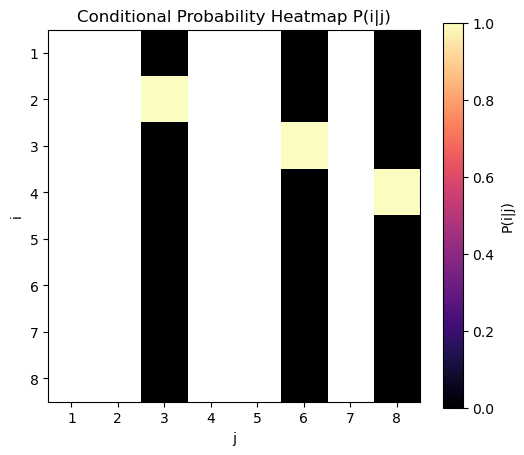

In [ ]:
print("Generating all elementary baskets (i, j) for i ≠ j ...\n")

# Generate all baskets of size 2 with i ≠ j
elementary_baskets = [[i, j] for i in range(8) for j in range(8) if i != j]

# Optionally, shuffle and duplicate for training
train_baskets = elementary_baskets * 500
random.shuffle(train_baskets)

print("Initializing weights ...\n")
init_weights()

print("Creating (context, target_item) pairs from synthetic baskets ...\n")
baskets_TI = []
for basket_items in train_baskets:
    target_item = random.choice(basket_items)
    context = Context(
        Basket(Wi, Wo, basket_items=basket_items, n_items=I, embedding_dim=K, n_items_basket=DEFAULT_N_ITEMS_BASKET),
        wa=wa,
        target_item=target_item
    )
    baskets_TI.append((context, target_item))

print("Training the model ...\n")
trainer = Trainer(baskets_TI, (Wi, wa, Wo), lr=L_R, K_noise=K_NOISE, epochs=TRAINING_EPOCHS)
loss_history = trainer.fit()

# --- Evaluation: Conditional probabilities P(j | i) ---

print("Evaluating conditional probabilities ...\n")
# For each i (context), for each j ≠ i, create basket [i, j] with context i and see if j is recommended
M = np.zeros((8, 8))  # M[i, j] = count of times j is recommended given context i

for i in range(8):
    for j in range(8):
        if i == j:
            continue
        basket_items = [i, j]
        # Context is i, target is j (but we want to see if j is recommended)
        context = Context(
            Basket(Wi, Wo, basket_items=basket_items, n_items=I, embedding_dim=K, n_items_basket=2),
            wa=wa,
            target_item=j
        )
        # Compute scores for all items
        scores = np.array([context.score(k).numpy() for k in range(8)])
        # Mask out the context item (i)
        scores[i] = -np.inf
        # Find the most recommended item
        most_recommended = np.argmax(scores)
        # If j is most recommended, count it
        if most_recommended == j:
            M[i, j] += 1

# Normalize to get probabilities P(j | i)
P = M / np.sum(M, axis=1, keepdims=True)
np.set_printoptions(precision=2, suppress=True)
print("Conditional probability matrix P(j | i):\n", P)

# Plot heatmap
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
plt.imshow(P, cmap='magma', interpolation='nearest')
plt.colorbar(label='P(j | i)')
plt.title('Conditional Probability Heatmap P(j | i)')
plt.xlabel('Recommended item j')
plt.ylabel('Context item i')
plt.xticks(ticks=np.arange(8), labels=np.arange(8))
plt.yticks(ticks=np.arange(8), labels=np.arange(8))
plt.show()